In [1]:
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
folder = '/Volumes/ESA_F4R/tropomi/tropomi2/'
F = 'S5P_PAL__L2__HDO__S_20180501T115123_20180501T133254_02839_01_100300_20250308T193126.nc'

In [3]:
x = xr.open_dataset(folder+F,
                    group="PRODUCT",
                    drop_variables=['level','corner','glintflag','ground_pixel','nwin',
                                    'hdo_column_precision','hdo_column_apriori',
                                    'hdo_profile_apriori','h2o_profile_apriori',
                                    'delta_time','layer',
                                    'h2o_column_precision','h2o_column_apriori'])
x = x.rename({'latitude':'lat','longitude':'lon'})
x = x.assign_coords({"ground_pixel": x.ground_pixel.values})
x['deltad'] = x['deltad']*1000.0
x.close()

In [4]:
print(x)

x = x.where(x['qa_value']>0.7)

<xarray.Dataset> Size: 4MB
Dimensions:           (time: 1, scanline: 569, ground_pixel: 215)
Coordinates:
  * time              (time) datetime64[ns] 8B 2018-05-01T12:12:59
  * scanline          (scanline) int32 2kB 1055 1056 1057 ... 1621 1622 1623
  * ground_pixel      (ground_pixel) int64 2kB 0 1 2 3 4 ... 210 211 212 213 214
    lat               (time, scanline, ground_pixel) float32 489kB ...
    lon               (time, scanline, ground_pixel) float32 489kB ...
Data variables:
    qa_value          (time, scanline, ground_pixel) float64 979kB ...
    h2o_column        (time, scanline, ground_pixel) float32 489kB ...
    deltad            (time, scanline, ground_pixel) float32 489kB -188.2 ......
    deltad_precision  (time, scanline, ground_pixel) float32 489kB ...
    hdo_column        (time, scanline, ground_pixel) float32 489kB ...


In [5]:
#H2O column conversion

#molec/cm**2

#cm**2 --> kg
#(pressure in Pa)*( area in m**2)/(gravity in m/s**2)
P = 101300 
A = 10**(-4)
g = 9.81 

conv_denom = P*A/g

#molec --> g
#(number of molecules)*(atomic weight in g/mol)/(avogadro number in molec/mol)
N = x['h2o_column']
AW = 18
AV = 6.02214076*10**23

conv_enum = N*AW/AV

x['h2o_vmr'] = conv_enum/conv_denom

print(x['h2o_vmr'])



<xarray.DataArray 'h2o_vmr' (time: 1, scanline: 569, ground_pixel: 215)> Size: 489kB
array([[[0.7740128, 1.1295941, 1.2630705, ..., 1.6906279, 1.8104934,
         2.2385848],
        [0.8409836, 1.1205264, 1.2827965, ...,       nan, 1.933365 ,
         2.379131 ],
        [0.8990038, 1.2363489, 1.3073003, ..., 1.7594773, 2.2816927,
         2.3670702],
        ...,
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan]]], shape=(1, 569, 215), dtype=float32)
Coordinates:
  * time          (time) datetime64[ns] 8B 2018-05-01T12:12:59
  * scanline      (scanline) int32 2kB 1055 1056 1057 1058 ... 1621 1622 1623
  * ground_pixel  (ground_pixel) int64 2kB 0 1 2 3 4 5 ... 210 211 212 213 214
    lat           (time, scanline, ground_pixel) float32 489kB -20.4 ... 20.27
    lon     

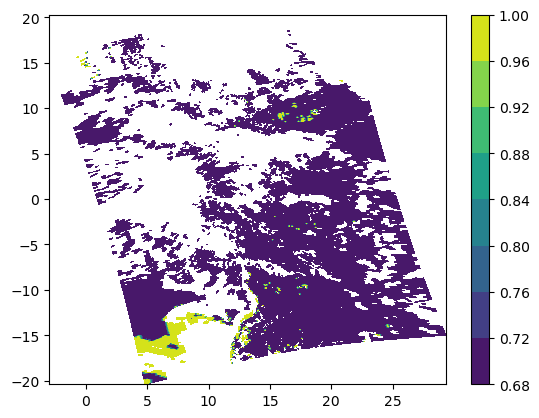

<Figure size 640x480 with 0 Axes>

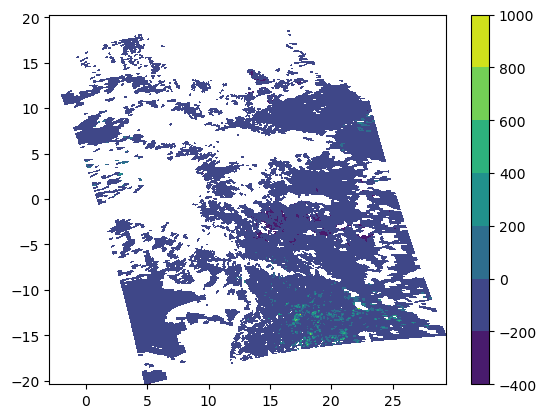

<Figure size 640x480 with 0 Axes>

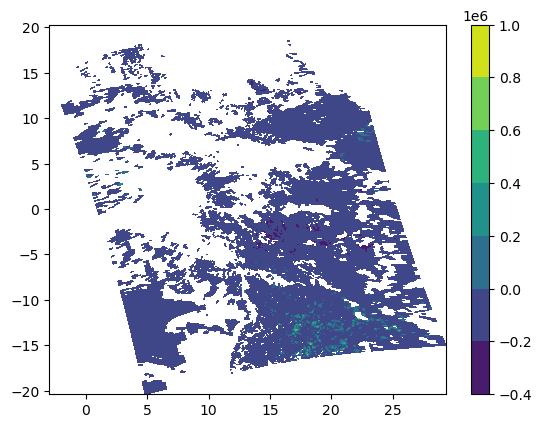

<Figure size 640x480 with 0 Axes>

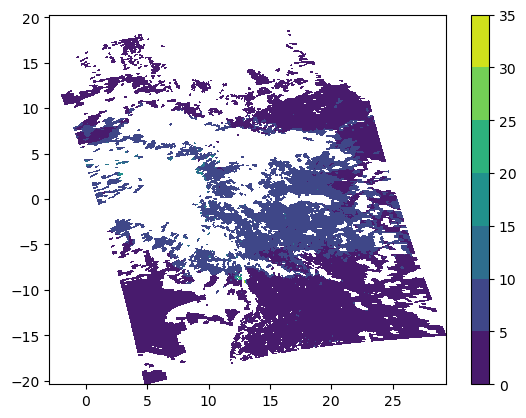

<Figure size 640x480 with 0 Axes>

In [6]:
xp = x['deltad'][0,:,:]
qa = x['qa_value'][0,:,:]
h2 = x['h2o_vmr'][0,:,:]

#Plot qa values
fig1,ax1 = plt.subplots()
cs1 = ax1.contourf(qa.lon,qa.lat,qa)
cbar = fig1.colorbar(cs1)
plt.show()
plt.clf()

#Plot deltad without conversion
fig1,ax1 = plt.subplots()
cs1 = ax1.contourf(xp.lon,xp.lat,xp)
cbar = fig1.colorbar(cs1)
plt.show()
plt.clf()

#Multiplying by 1000 to convert to permil
fig2,ax2 = plt.subplots()
xpc = xp*1000.0
cs2 = ax2.contourf(xpc.lon,xp.lat,xpc)
cbar = fig2.colorbar(cs2)
plt.show()
plt.clf()

#H2O column
fig2,ax2 = plt.subplots()
cs3 = ax2.contourf(h2.lon,h2.lat,h2)
cbar = fig2.colorbar(cs3)
plt.show()
plt.clf()


/Users/ellendyer/miniconda3/envs/isotope_env/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'kind'
  cset = contour_func(


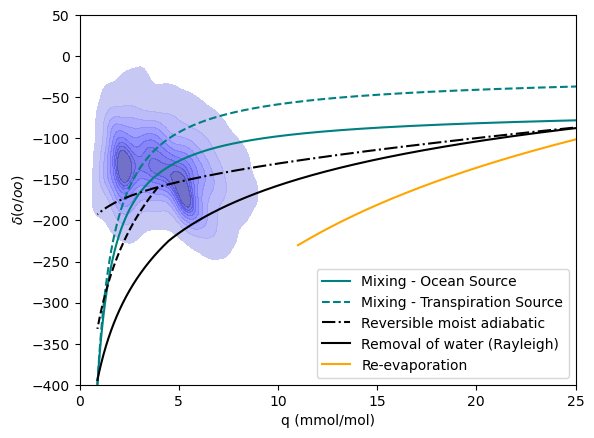

In [7]:
import NooneCurves as NC
import seaborn as sns

# Some initial values for testing
del0 = -400.    # Try -360 ....
delp = -30. 
eta  = 0.995
hsrc = 0.80 
nn   = 1000     # It needs to be this large to get precision in the searches
pcld = 85000.
ps = 1000.e2                    # approximate surface pressure
q0   = 0.9 
qmin = 11.
tsrc = 300. 

df = x.to_dataframe()

sns.kdeplot(data=df, x="h2o_vmr", y="deltad", kind="kde", fill=True, 
            alpha=0.8,color='blue')
            #levels=5, thresh=.2,)

plt.ylim(-400,50)
plt.xlim(0,25)

NC.noone_curves(tsrc,q0,del0)    # Run and produce plot

plt.legend(loc='best')

plt.show()
plt.clf()
plt.close()